In [3]:
from google.colab import files
uploaded = files.upload()


Saving customer_support_dataset.csv to customer_support_dataset.csv


In [4]:
import pandas as pd

df = pd.read_csv("customer_support_dataset.csv")
df.head()


,Ticket_ID,Customer_Name,Issue_Type,Description,Priority
0,101,Ravi,Login Problem,Unable to login since morning,High
1,102,Anita,Payment Failed,Payment deducted but order not placed,Medium
2,103,Kumar,App Crash,App crashes when opening profile,High
3,104,Sneha,Slow Performance,App is very slow after update,Low
4,105,Arjun,Account Locked,Account locked after multiple attempts,High


In [7]:
df.columns


Index(['Ticket_ID', 'Customer_Name', 'Issue_Type', 'Description', 'Priority'], dtype='object')

In [8]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Cleaned_Description"] = df["Description"].apply(clean_text)
df.head()


,Ticket_ID,Customer_Name,Issue_Type,Description,Priority,Cleaned_Description
0,101,Ravi,Login Problem,Unable to login since morning,High,unable to login since morning
1,102,Anita,Payment Failed,Payment deducted but order not placed,Medium,payment deducted but order not placed
2,103,Kumar,App Crash,App crashes when opening profile,High,app crashes when opening profile
3,104,Sneha,Slow Performance,App is very slow after update,Low,app is very slow after update
4,105,Arjun,Account Locked,Account locked after multiple attempts,High,account locked after multiple attempts


In [9]:
df["Normalized_Issue"] = df["Issue_Type"].str.lower()
df["Normalized_Priority"] = df["Priority"].str.lower()

df.head()


,Ticket_ID,Customer_Name,Issue_Type,Description,Priority,Cleaned_Description,Normalized_Issue,Normalized_Priority
0,101,Ravi,Login Problem,Unable to login since morning,High,unable to login since morning,login problem,high
1,102,Anita,Payment Failed,Payment deducted but order not placed,Medium,payment deducted but order not placed,payment failed,medium
2,103,Kumar,App Crash,App crashes when opening profile,High,app crashes when opening profile,app crash,high
3,104,Sneha,Slow Performance,App is very slow after update,Low,app is very slow after update,slow performance,low
4,105,Arjun,Account Locked,Account locked after multiple attempts,High,account locked after multiple attempts,account locked,high


In [10]:
def chunk_text(text, chunk_size=4):
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

df["Chunks"] = df["Cleaned_Description"].apply(chunk_text)
df[["Description", "Chunks"]]


,Description,Chunks
0,Unable to login since morning,"[unable to login since, morning]"
1,Payment deducted but order not placed,"[payment deducted but order, not placed]"
2,App crashes when opening profile,"[app crashes when opening, profile]"
3,App is very slow after update,"[app is very slow, after update]"
4,Account locked after multiple attempts,"[account locked after multiple, attempts]"


In [11]:
documents = []

for _, row in df.iterrows():
    for chunk in row["Chunks"]:
        documents.append({
            "ticket_id": row["Ticket_ID"],
            "customer": row["Customer_Name"],
            "issue_type": row["Normalized_Issue"],
            "priority": row["Normalized_Priority"],
            "text_chunk": chunk
        })

indexed_df = pd.DataFrame(documents)
indexed_df.head()


,ticket_id,customer,issue_type,priority,text_chunk
0,101,Ravi,login problem,high,unable to login since
1,101,Ravi,login problem,high,morning
2,102,Anita,payment failed,medium,payment deducted but order
3,102,Anita,payment failed,medium,not placed
4,103,Kumar,app crash,high,app crashes when opening


In [12]:
indexed_df.to_csv("index_ready_tickets.csv", index=False)


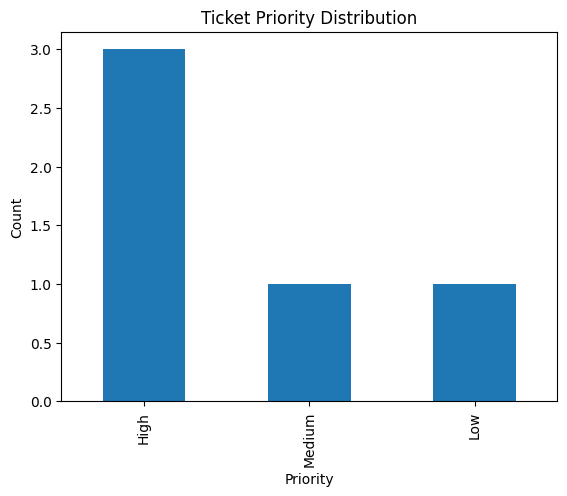

In [13]:
import matplotlib.pyplot as plt

priority_counts = df["Priority"].value_counts()

plt.figure()
priority_counts.plot(kind="bar")
plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()
